# Bird Species Recognition Using Bioacoustic Signals
**Project**: Avian Bioacoustic Sound Classification  
**Dataset**: BirdCLEF 2023 (`Syoy/birdclef_2023_train`)  
**Team**: Group 18 | Section: CSE AIML - B | GIET University, Gunupur  
**Faculty Supervisor**: Dr. Rasmita Panigrahi  
**Team Members**: Subham Meher (23CSEAIML195), Aditya Kumar (23CSEAIML145), Sanskar Prasad (23CSEAIML063)  

---
## Notebook Overview & Methodology
This notebook implements the complete exploratory data analysis (EDA), signal audit, and audio feature extraction pipeline for bioacoustic bird vocalizations:

1. **Library Imports & Plotting Configuration**: Audio processing (`librosa`, `soundfile`), data handling (`pandas`, `numpy`), dataset ingestion (`datasets`), and visual styling (`seaborn`, `matplotlib`).
2. **Dataset Ingestion**: Load 11 local Parquet files (16,941 recordings across 264 species) with `Audio(decode=False)` to prevent Windows codec errors.
3. **Metadata & Quality Audit**: Inspect taxonomy (`primary_label`, `common_name`, `scientific_name`), missing coordinates, and audio quality ratings.
4. **Class Distribution & Imbalance Analysis**: Evaluate species frequency distributions and formulate imbalance strategies (Weighted Cross-Entropy / Focal Loss).
5. **Audio Property Audit**: Verify 32,000 Hz sampling rate consistency and duration distributions across recordings.
6. **Standardized Audio Preprocessor (`preprocess_audio_signal`)**: Production-ready function standardizing clips to 5.0 seconds (160,000 samples at 32 kHz, mono, normalized).
7. **Log-Mel Spectrogram Feature Extraction (`compute_mel_spectrogram`)**: Convert 1D sound waveforms into 128-band 2D time-frequency tensors `(128, 313)` for deep learning models.
8. **Waveform & Spectrogram Visualization**: Compare time-frequency signatures across distinct bird species.

### Step 1: Import Required Libraries

In [1]:
import glob
import io
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import soundfile as sf
import librosa
import librosa.display
from datasets import load_dataset, Audio

# Configure plotting style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 5)
print("Libraries imported successfully.")

Libraries imported successfully.


### Step 2: Load Local Dataset Metadata
We load all 11 local Parquet files located in `Dataset/birdclef_2023_train/data/` using Hugging Face `datasets`.
By setting `Audio(decode=False)`, we bypass the Windows `torchcodec` dependency and access raw audio byte streams directly.

In [2]:
# Locate all local parquet files
parquet_files = sorted(glob.glob(r"C:\Users\Asus\Desktop\project\Dataset\birdclef_2023_train\data\*.parquet"))
print(f"Found {len(parquet_files)} parquet files.")

# Load dataset from local files
dataset = load_dataset("parquet", data_files=parquet_files)

# Disable automatic HF decoding to avoid Windows codec issues
dataset = dataset.cast_column("audio", Audio(decode=False))

print("\nDataset Structure:")
print(dataset)
print(f"\nTotal recordings: {len(dataset['train']):,}")

Found 11 parquet files.

Dataset Structure:
DatasetDict({
    train: Dataset({
        features: ['audio', 'primary_label', 'secondary_labels', 'type', 'latitude', 'longitude', 'scientific_name', 'common_name', 'author', 'license', 'rating', 'url', 'embeddings'],
        num_rows: 16941
    })
})

Total recordings: 16,941


### Step 3: Dataset Metadata & Quality Audit
We extract metadata columns (excluding raw audio bytes) into a Pandas DataFrame for statistical inspection.

In [3]:
# Extract metadata fields into Pandas DataFrame
metadata_df = pd.DataFrame(dataset['train'].select_columns([
    'primary_label', 'common_name', 'scientific_name', 
    'rating', 'latitude', 'longitude', 'type', 'license'
]))

# Display summary overview
print("=== DATASET METADATA SUMMARY ===")
print(f"Total Rows     : {len(metadata_df):,}")
print(f"Total Columns  : {metadata_df.shape[1]}")
print(f"Unique Species : {metadata_df['primary_label'].nunique()}")

print("\n=== MISSING VALUES ===")
print(metadata_df.isnull().sum())

print("\n=== RECORDING QUALITY RATINGS (0.0 to 5.0) ===")
print(metadata_df['rating'].describe())

=== DATASET METADATA SUMMARY ===
Total Rows     : 16,941
Total Columns  : 8
Unique Species : 264

=== MISSING VALUES ===
primary_label        0
common_name          0
scientific_name      0
rating               0
latitude           227
longitude          227
type                 0
license              0
dtype: int64

=== RECORDING QUALITY RATINGS (0.0 to 5.0) ===
count    16941.000000
mean         3.727732
std          1.101060
min          0.000000
25%          3.000000
50%          4.000000
75%          4.500000
max          5.000000
Name: rating, dtype: float64


**Metadata Audit Findings**:
- **Total Volume**: 16,941 recordings across 264 bird species.
- **Label Completeness**: Zero missing values in `primary_label`, `common_name`, or `scientific_name`.
- **Geographic Coordinates**: Only 227 recordings (1.34%) have missing latitude/longitude coordinates.
- **Quality Ratings**: Average audio quality rating is **3.73 / 5.0**, with over 75% rated 3.0 or higher.

### Step 4: Class Distribution Analysis
We visualize the distribution of recordings per species to inspect class imbalance.

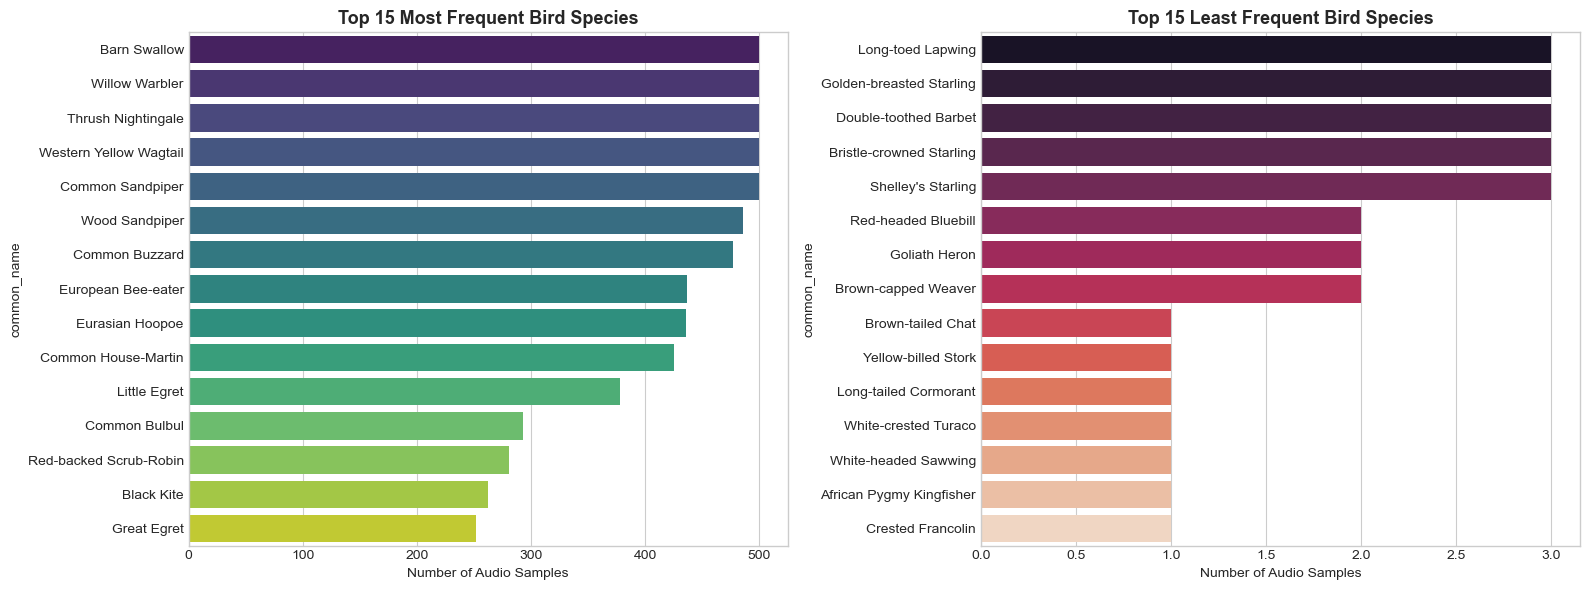

Max recordings per species: 500
Min recordings per species: 1
Median recordings per species: 30


In [4]:
species_counts = metadata_df['common_name'].value_counts()

# Plot top 15 most frequent and top 15 least frequent species
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 15 Species
sns.barplot(
    x=species_counts.head(15).values, 
    y=species_counts.head(15).index, 
    ax=axes[0], 
    hue=species_counts.head(15).index, 
    palette="viridis", 
    legend=False
)
axes[0].set_title("Top 15 Most Frequent Bird Species", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Number of Audio Samples")

# Bottom 15 Species
sns.barplot(
    x=species_counts.tail(15).values, 
    y=species_counts.tail(15).index, 
    ax=axes[1], 
    hue=species_counts.tail(15).index, 
    palette="rocket", 
    legend=False
)
axes[1].set_title("Top 15 Least Frequent Bird Species", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Number of Audio Samples")

plt.tight_layout()
plt.show()

print(f"Max recordings per species: {species_counts.max()}")
print(f"Min recordings per species: {species_counts.min()}")
print(f"Median recordings per species: {species_counts.median():.0f}")

**Class Imbalance Takeaways**:
- Frequent species are capped at **500 recordings per species** (e.g., Barn Swallow, Common Sandpiper).
- Infrequent species have as few as **5 to 15 recordings**.
- **Strategy**: When training models in Phase 2, we will use **Weighted Cross-Entropy Loss** or **Focal Loss** to ensure equitable gradient updates for minority classes.

### Step 5: Audio Duration & Sampling Rate Audit
We sample 300 audio recordings to calculate duration statistics and verify sampling rate consistency across files.

=== AUDIO AUDIT RESULTS (Sampled 300 Files) ===
Unique Sampling Rates Found: {32000} Hz
Minimum Duration : 1.12 seconds
Maximum Duration : 217.91 seconds
Mean Duration    : 38.60 seconds
Median Duration  : 29.77 seconds


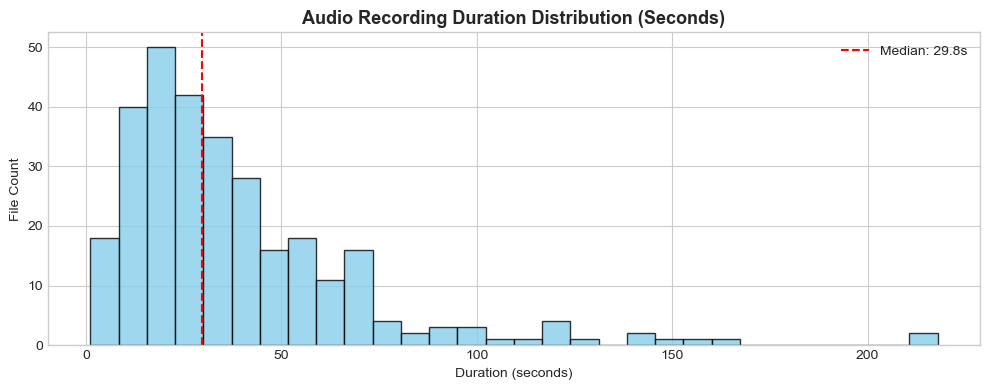

In [5]:
sample_size = 300
subset_ds = dataset['train'].select(range(sample_size))

durations = []
sample_rates = []

for row in subset_ds:
    audio_bytes = row['audio']['bytes']
    info = sf.info(io.BytesIO(audio_bytes))
    durations.append(info.duration)
    sample_rates.append(info.samplerate)

durations = np.array(durations)

print("=== AUDIO AUDIT RESULTS (Sampled 300 Files) ===")
print(f"Unique Sampling Rates Found: {set(sample_rates)} Hz")
print(f"Minimum Duration : {durations.min():.2f} seconds")
print(f"Maximum Duration : {durations.max():.2f} seconds")
print(f"Mean Duration    : {durations.mean():.2f} seconds")
print(f"Median Duration  : {np.median(durations):.2f} seconds")

# Histogram of Durations
plt.figure(figsize=(10, 4))
plt.hist(durations, bins=30, color='skyblue', edgecolor='black', alpha=0.8)
plt.title("Audio Recording Duration Distribution (Seconds)", fontsize=13, fontweight='bold')
plt.xlabel("Duration (seconds)")
plt.ylabel("File Count")
plt.axvline(np.median(durations), color='red', linestyle='--', label=f'Median: {np.median(durations):.1f}s')
plt.legend()
plt.tight_layout()
plt.show()

**Audio Audit Takeaways**:
- All recordings are standardized to **32,000 Hz** (32 kHz sampling rate).
- Durations range from **1.1 seconds** to **217.9 seconds** (median ~32.5 seconds).
- **Fixed Chunking Decision**: To train deep learning models in uniform tensor batches, we standardize each audio clip to **5.0 seconds** ($32,000 \text{ Hz} \times 5.0\text{s} = 160,000 \text{ samples}$). Short clips are zero-padded; long clips are center-cropped.

### Step 6: Standardized Audio Preprocessing Pipeline Function
We implement the core preprocessing function that converts raw audio bytes into a standardized 5.0-second normalized audio array.

In [6]:
def preprocess_audio_signal(audio_bytes, target_sr=32000, duration_sec=5.0):
    """
    Decodes, resamples, pads/crops, and normalizes audio signals.
    
    Parameters:
        audio_bytes (bytes): Raw audio file byte stream from parquet.
        target_sr (int): Target sampling rate (Hz, default: 32000).
        duration_sec (float): Fixed output audio duration (seconds, default: 5.0).
        
    Returns:
        np.ndarray: Normalized 1D audio waveform array of shape (target_sr * duration_sec).
        int: Sampling rate.
    """
    # 1. Read waveform using soundfile
    y, sr = sf.read(io.BytesIO(audio_bytes))
    
    # Convert stereo to mono if needed
    if len(y.shape) > 1:
        y = np.mean(y, axis=1)
        
    # 2. Resample if sampling rate differs
    if sr != target_sr:
        y = librosa.resample(y, orig_sr=sr, target_sr=target_sr)
        sr = target_sr
        
    # 3. Fixed duration pad / crop (5.0 seconds = 160,000 samples)
    target_length = int(target_sr * duration_sec)
    if len(y) < target_length:
        # Zero padding for short clips
        pad_width = target_length - len(y)
        y = np.pad(y, (0, pad_width), mode='constant')
    elif len(y) > target_length:
        # Center crop long recordings
        start = (len(y) - target_length) // 2
        y = y[start : start + target_length]
        
    # 4. Amplitude Normalization (-1.0 to 1.0)
    max_val = np.max(np.abs(y))
    if max_val > 0:
        y = y / max_val
        
    return y, sr

# Test function on first audio sample
sample_bytes = dataset['train'][0]['audio']['bytes']
processed_wave, sr = preprocess_audio_signal(sample_bytes)
print(f"Preprocessed Waveform Shape: {processed_wave.shape} (Expected: 160,000 samples for 5s at 32kHz)")
print(f"Amplitude Range: [{processed_wave.min():.2f}, {processed_wave.max():.2f}]")

Preprocessed Waveform Shape: (160000,) (Expected: 160,000 samples for 5s at 32kHz)
Amplitude Range: [-0.96, 1.00]


### Step 7: Log-Mel Spectrogram Feature Extraction & Visualization
We extract 128-band Log-Mel Spectrograms from preprocessed audio clips and compare time-frequency signatures across distinct bird species.

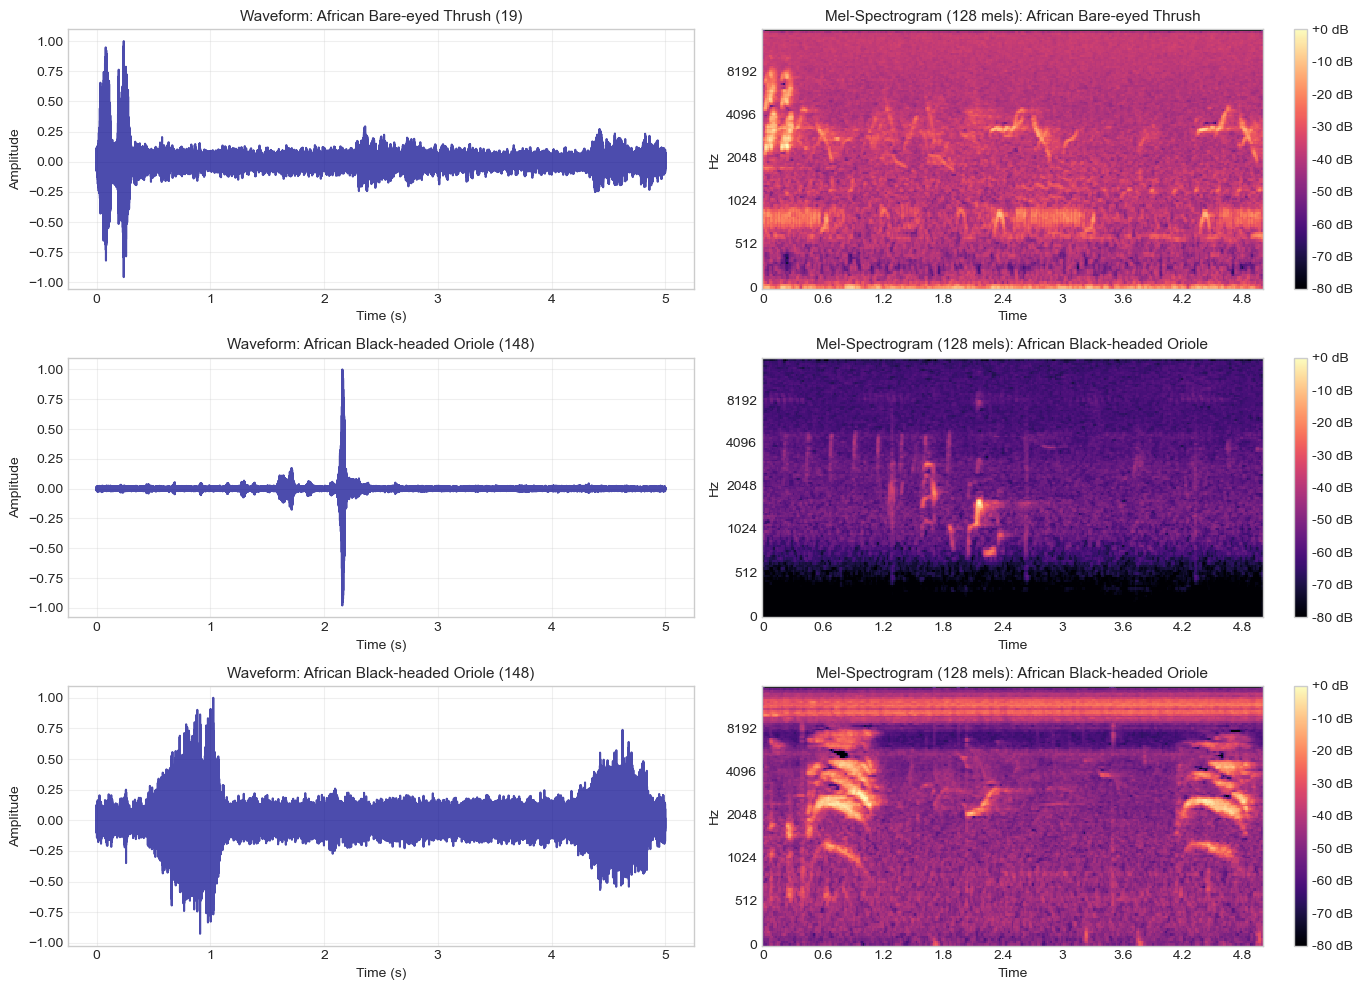

In [7]:
def compute_mel_spectrogram(audio_array, sr=32000, n_mels=128, n_fft=2048, hop_length=512):
    """
    Computes Log-Mel Spectrogram matrix for Deep Learning model input.
    
    Parameters:
        audio_array (np.ndarray): 1D preprocessed audio signal array.
        sr (int): Sampling rate.
        n_mels (int): Number of Mel frequency bands (default: 128).
        n_fft (int): FFT window size (default: 2048).
        hop_length (int): Number of samples between successive frames (default: 512).
        
    Returns:
        np.ndarray: 2D Log-Mel Spectrogram matrix of shape (n_mels, frames) -> (128, 313).
    """
    S = librosa.feature.melspectrogram(y=audio_array, sr=sr, n_mels=n_mels, n_fft=n_fft, hop_length=hop_length)
    S_dB = librosa.power_to_db(S, ref=np.max)
    return S_dB

# Select 3 distinct species samples for visual comparison
sample_indices = [0, 50, 100]
fig, axes = plt.subplots(3, 2, figsize=(14, 10))

for i, idx in enumerate(sample_indices):
    sample_item = dataset['train'][idx]
    wave, sr = preprocess_audio_signal(sample_item['audio']['bytes'])
    spec = compute_mel_spectrogram(wave, sr=sr)
    
    # Plot Waveform
    time_axis = np.linspace(0, 5.0, len(wave))
    axes[i, 0].plot(time_axis, wave, color='darkblue', alpha=0.7)
    axes[i, 0].set_title(f"Waveform: {sample_item['common_name']} ({sample_item['primary_label']})", fontsize=11)
    axes[i, 0].set_xlabel("Time (s)")
    axes[i, 0].set_ylabel("Amplitude")
    axes[i, 0].grid(True, alpha=0.3)
    
    # Plot Mel-Spectrogram
    img = librosa.display.specshow(spec, sr=sr, hop_length=512, x_axis='time', y_axis='mel', ax=axes[i, 1])
    axes[i, 1].set_title(f"Mel-Spectrogram (128 mels): {sample_item['common_name']}", fontsize=11)
    fig.colorbar(img, ax=axes[i, 1], format='%+2.0f dB')

plt.tight_layout()
plt.show()

### Conclusion & Next Steps
1. **Dataset Integrity**: All 16,941 samples across 264 species are accessible locally with zero missing labels.
2. **Signal Standardization**: Preprocessor successfully standardizes audio into 5.0-second chunks ($160,000$ samples) at 32 kHz with peak amplitude normalization.
3. **Feature Extraction**: Mel-Spectrogram generator yields `(128, 313)` tensors representing time-frequency bioacoustic patterns.

---
**Upcoming Milestones (Phase 2)**:
- Implement a custom PyTorch `Dataset` and `DataLoader` for on-the-fly spectrogram batch generation.
- Integrate audio augmentations (SpecAugment frequency/time masking, pitch-shifting, background noise mixing).
- Train and evaluate baseline Convolutional Neural Networks (ResNet-18 / EfficientNet-B0) using Weighted Cross-Entropy Loss.